<div class="cover">

# Lab 4 — Classification and Evaluation

**Name:** Hadi Muneer Abu Allairat<br>
**Student ID:** 2230005761<br>
**Dataset:** Amazon Reviews of Unlocked Mobile Phones

</div>


**Use case:** sentiment analysis on Amazon reviews of unlocked mobile phones, classified into
positive / neutral / negative.

Dataset: `PromptCloudHQ/amazon-reviews-unlocked-mobile-phones`.

| Task | |
| --- | --- |
| 1 | Load the data and apply 5 different preprocessing steps |
| 2 | Use a proper train/test split |
| 3 | Feature extraction with TF-IDF |
| 4 | Train a Naive Bayes classifier |
| 5 | Evaluate on the test set |
| 6 | Print the confusion matrix |

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

DATA_DIR = Path("data")
RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 110)

## Task 1 — Loading the data

In [2]:
csv_path = DATA_DIR / "Amazon_Unlocked_Mobile.csv"

if not csv_path.exists():
    import kagglehub

    cache = kagglehub.dataset_download("PromptCloudHQ/amazon-reviews-unlocked-mobile-phones")
    csv_path = next(Path(cache).glob("*.csv"))

data = pd.read_csv(csv_path, low_memory=False)
print(data.shape)
data.head(3)

(413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOUCH SCREEN",Samsung,199.99,5,"I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from someone w...",1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOUCH SCREEN",Samsung,199.99,4,"nice phone, nice up grade from my pantach revue. Very clean set up and easy set up. never had an android p...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOUCH SCREEN",Samsung,199.99,5,Very pleased,0.0


In [3]:
data.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

In [4]:
data = data.dropna(subset=["Reviews", "Rating"]).copy()
print(f"Rows with both a review and a rating: {len(data):,}")
data["Rating"].value_counts().sort_index()

Rows with both a review and a rating: 413,770


Rating
1     72335
2     24724
3     31763
4     61373
5    223575
Name: count, dtype: int64

### Deriving the labels

The dataset has no sentiment column, only a 1–5 star rating, so the labels are derived the same way
as in the Disneyland walkthrough: 4–5 positive, 3 neutral, 1–2 negative.

In [5]:
def to_sentiment(rating):
    if rating > 3:
        return "positive"
    if rating < 3:
        return "negative"
    return "neutral"


data["Sentiment"] = data["Rating"].apply(to_sentiment)

distribution = data["Sentiment"].value_counts()
pd.DataFrame({
    "reviews": distribution,
    "share": (distribution / len(data)).map("{:.1%}".format),
})

,reviews,share
Sentiment,,
positive,284948,68.9%
negative,97059,23.5%
neutral,31763,7.7%


The classes are badly imbalanced: roughly 69% positive against 8% neutral. Two consequences follow,
and both shape how this model has to be evaluated.

First, **accuracy is a weak metric here** — predicting "positive" for every review already scores
about 0.69 without learning anything. Some version of that number, recomputed on the actual test
split, is the baseline any result has to beat.

Second, **neutral is going to be the hard class**. It is the rarest, and a 3-star review is
genuinely mixed text ("good phone but the battery is poor") that shares vocabulary with both other
classes. I expect its recall to be poor and I check for that in Task 5 rather than hiding it behind
an overall accuracy figure.

In [6]:
SAMPLE_SIZE = 60_000

if len(data) > SAMPLE_SIZE:
    frac = SAMPLE_SIZE / len(data)
    picked = [
        group.sample(int(round(len(group) * frac)), random_state=RANDOM_STATE)
        for _, group in data.groupby("Sentiment")
    ]
    data = pd.concat(picked).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Working sample: {len(data):,} reviews")
print(data["Sentiment"].value_counts(normalize=True).round(3).to_dict())

Working sample: 60,000 reviews
{'positive': 0.689, 'negative': 0.235, 'neutral': 0.077}


I work on a stratified 60,000-review sample rather than all 414,000. Lemmatising the full set takes
several minutes for no change in the conclusions, and stratifying keeps the class proportions
identical to the original, so the imbalance discussed above is preserved exactly.

### The five preprocessing steps

Looking at the raw review text first, to decide what actually needs removing:

In [7]:
for text in data["Reviews"].head(3):
    print("-", text[:180], "\n")

- Help is impossible both on the phone and online. It keeps making notification sounds that mean nothing--or give no reason. It is run by Google on all levels--very irritating. We wa 

- Nice phone 

- Just Love this Phone....Samsung the only way to go! 



In [8]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

# Negations carry the sentiment, so they are kept even though NLTK lists them as stopwords.
NEGATIONS = {"not", "no", "nor", "never", "none", "cannot", "don", "didn", "doesn",
             "isn", "wasn", "aren", "weren", "won", "wouldn", "couldn", "shouldn", "hasn", "hadn"}
STOPWORDS = set(stopwords.words("english")) - NEGATIONS

URL = re.compile(r"https?://\S+|www\.\S+")
HTML = re.compile(r"<[^>]+>|&\w+;")
NON_LETTER = re.compile(r"[^a-z\s]")
SPACES = re.compile(r"\s+")


def preprocess(text):
    text = URL.sub(" ", HTML.sub(" ", text))     # 1. strip URLs and HTML artefacts
    text = text.lower()                          # 2. lowercase
    text = NON_LETTER.sub(" ", text)             # 3. drop punctuation, digits and symbols
    tokens = word_tokenize(SPACES.sub(" ", text))  # 4. tokenise
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]  # 5. stopwords, short tokens
    return " ".join(lemmatizer.lemmatize(t, pos="v") for t in tokens)  # 6. lemmatise

The steps, and why each one is here:

1. **URL and HTML removal** — every link is unique, so each would become a vocabulary entry used by
   exactly one document.
2. **Lowercasing** — collapses `Phone`, `phone` and `PHONE` into one feature instead of three.
3. **Removing punctuation, digits and symbols** — model numbers like `S7` and prices vary per
   product and would let the classifier key on the product rather than the sentiment.
4. **Tokenisation** — splits on the linguistic unit rather than whitespace.
5. **Stopword removal, with negations preserved** — this is the one deliberate departure from the
   default recipe, and the next cell shows why.
6. **Lemmatisation** — maps `bought`/`buying`/`buys` to `buy`, so inflected forms share a feature.
   I chose lemmatisation over stemming because it returns real words, which keeps the
   most-informative-feature table in Task 5 readable.

In [9]:
example = "I did not like this phone. It was NOT good at all!! Battery died after 2 days."

default_stops = set(stopwords.words("english"))
naive = " ".join(
    lemmatizer.lemmatize(t, pos="v")
    for t in word_tokenize(NON_LETTER.sub(" ", example.lower()))
    if t not in default_stops and len(t) > 2
)

print("raw:                    ", example)
print("stopwords removed naively:", naive)
print("negations preserved:    ", preprocess(example))

raw:                     I did not like this phone. It was NOT good at all!! Battery died after 2 days.
stopwords removed naively: like phone good battery die days
negations preserved:     not like phone not good battery die days


Stripping the full stopword list turns "did not like" and "NOT good" into "like" and "good" — the
review reads as positive after preprocessing even though it is plainly negative. Keeping the
negations is not a stylistic preference; without it the labels and the features disagree on exactly
the reviews that matter most.

In [10]:
%%time
data["clean_text"] = data["Reviews"].astype(str).map(preprocess)

CPU times: total: 10.1 s
Wall time: 10.2 s


In [11]:
before = len(data)
data = data[data["clean_text"].str.split().str.len() >= 2].reset_index(drop=True)
print(f"Dropped {before - len(data):,} reviews that were left with fewer than 2 tokens")
print(data["Sentiment"].value_counts(normalize=True).round(3).to_dict())

data[["Reviews", "clean_text", "Rating", "Sentiment"]].head()

Dropped 7,641 reviews that were left with fewer than 2 tokens
{'positive': 0.654, 'negative': 0.263, 'neutral': 0.083}


,Reviews,clean_text,Rating,Sentiment
0,Help is impossible both on the phone and online. It keeps making notification sounds that mean nothing--or...,help impossible phone online keep make notification sound mean nothing give reason run google level irrita...,1,negative
1,Nice phone,nice phone,4,positive
2,Just Love this Phone....Samsung the only way to go!,love phone samsung way,5,positive
3,I ordered this phone excited about the price and features. Got this phone today...STarted it...it is in so...,order phone excite price feature get phone today start language never specify language call bluetekus coup...,1,negative
4,"I imagine the phone is fine, but I've ordered two different BLU phones in the last week (this one and a St...",imagine phone fine order two different blu phone last week one studio energy ship defective usb charge cab...,1,negative


Dropping the near-empty reviews shifts the class balance noticeably — positive falls from 69% to
around 65%. That is not random: the reviews that reduce to nothing are the very short ones
("Nice phone", "Love it", "A+++"), and short reviews skew positive. Satisfied customers write one
line; dissatisfied ones explain themselves.

So the majority-class baseline for this experiment is the post-filter figure, not the 69% from the
raw dataset. I compute it directly from the test labels in Task 5 rather than quoting it.

## Task 2 — Train/test split

Two things make this split "proper":

- **`stratify`** — with an 8% neutral class, an unstratified random split can easily give the train
  and test sets different class balances, which makes the test score partly a measure of the split.
- **Splitting before vectorising** — `TfidfVectorizer` learns the vocabulary and the IDF weights
  from the data it is fitted on. Fitting it on everything first would let corpus statistics from the
  test set leak into the training features and inflate the score.

In [12]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    data["clean_text"],
    data["Sentiment"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=data["Sentiment"],
)

print(f"train: {train_data.shape[0]:,}    test: {test_data.shape[0]:,}")
pd.DataFrame({
    "train": train_labels.value_counts(normalize=True).round(3),
    "test": test_labels.value_counts(normalize=True).round(3),
})

train: 41,887    test: 10,472


,train,test
Sentiment,,
positive,0.654,0.654
negative,0.263,0.263
neutral,0.083,0.083


## Task 3 — Feature extraction with TF-IDF

TF-IDF weights a term by how often it appears in a document against how rare it is across the
corpus, so a word like `phone` — present in nearly every review — is down-weighted automatically
while `refund` or `flawless` keeps its weight.

Two parameter choices beyond the defaults:

- `ngram_range=(1, 2)` includes bigrams, which is what lets the model represent `not work` as a
  single feature rather than two independent tokens. Given the effort spent preserving negations in
  Task 1, unigrams alone would have wasted that.
- `min_df=3` drops terms appearing in fewer than three documents. As Lab 2 showed, the majority of
  distinct terms occur once; they cannot generalise and they triple the feature count.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print(f"train matrix: {train_vectors.shape}")
print(f"test matrix:  {test_vectors.shape}")
print(f"density:      {train_vectors.nnz / np.prod(train_vectors.shape):.4%}")

train matrix: (41887, 68933)
test matrix:  (10472, 68933)
density:      0.0473%


The matrix is over 99.9% zeros, which is normal for text: each review touches a few dozen of the
tens of thousands of features. `scipy` stores only the non-zero entries, which is why a
60,000 × 100,000 matrix fits in memory at all.

In [14]:
feature_names = tfidf_vectorizer.get_feature_names_out()
idf = pd.Series(tfidf_vectorizer.idf_, index=feature_names)

pd.DataFrame({
    "lowest IDF (common, low weight)": idf.nsmallest(10).index,
    "highest IDF (rare, high weight)": idf.nlargest(10).index,
})

,"lowest IDF (common, low weight)","highest IDF (rare, high weight)"
0,phone,abd
1,not,ability connect
2,work,ability hold
3,great,ability phone
4,good,ability upgrade
5,use,able answer
6,get,able come
7,buy,able customize
8,like,able determine
9,love,able give


The low-IDF column is the informative one: `phone`, `work`, `use`, `get` appear in nearly every
review and are weighted down accordingly — TF-IDF has effectively discovered a domain-specific
stopword list on its own, without being told that `phone` is uninformative in a corpus of phone
reviews.

The high-IDF column is less meaningful than it looks. `min_df=3` sets a floor, so thousands of terms
are tied at exactly the same maximum IDF and the ordering within that tie is alphabetical — which is
why it reads as a list of terms beginning with "ab". It is the *tie*, not the ranking, that is the
real observation.

Note also that `not` sits in the low-IDF list. It survived preprocessing, appears everywhere, and is
therefore weighted down — which is a reason the bigram features matter more than the `not` unigram
on its own.

## Task 4 — Training a Naive Bayes classifier

`MultinomialNB` is the standard Naive Bayes variant for term-count features. Its "naive" assumption
is that terms are conditionally independent given the class — plainly false for language, but it
makes training a single pass over the matrix, and it works well on high-dimensional sparse text.

In [15]:
%%time
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB(alpha=0.1)
nb_classifier.fit(train_vectors, train_labels)

predictions = nb_classifier.predict(test_vectors)

CPU times: total: 62.5 ms
Wall time: 68.3 ms


`alpha` is the same add-one smoothing idea from Lab 3: it stops an unseen (term, class) pair from
zeroing out the whole product of probabilities. The default of 1.0 is a heavy prior for a vocabulary
this large, so I lower it to 0.1.

## Task 5 — Evaluating on the test set

In [16]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

accuracy = accuracy_score(test_labels, predictions)
baseline = test_labels.value_counts(normalize=True).max()

print(f"Accuracy:              {accuracy:.3f}")
print(f"Majority-class baseline: {baseline:.3f}")
print(f"Macro F1:              {f1_score(test_labels, predictions, average='macro'):.3f}")
print(f"Weighted F1:           {f1_score(test_labels, predictions, average='weighted'):.3f}")

Accuracy:              0.869
Majority-class baseline: 0.654
Macro F1:              0.678
Weighted F1:           0.848


In [17]:
print(classification_report(test_labels, predictions, digits=3))

              precision    recall  f1-score   support

    negative      0.813     0.853     0.832      2757
     neutral      0.784     0.167     0.276       867
    positive      0.893     0.964     0.927      6848

    accuracy                          0.869     10472
   macro avg      0.830     0.661     0.678     10472
weighted avg      0.863     0.869     0.848     10472



The per-class breakdown is where the interesting result is, and it is the reason the macro F1 sits so
far below the accuracy.

- **Positive** is handled well — it is the majority class and its vocabulary is distinctive.
- **Negative** is respectable, helped by the preserved negations and the bigram features.
- **Neutral** is the failure case, with recall far below the other two. This is the outcome predicted
  in Task 1 and it has two causes that compound: neutral is the smallest class, so the prior works
  against it, and 3-star reviews are mixed text whose vocabulary genuinely overlaps both neighbours.

Reporting only the accuracy figure would hide all of this, which is exactly why the macro average
matters on an imbalanced problem — it weights each class equally instead of letting the majority
class dominate.

In [18]:
classes = nb_classifier.classes_
log_prob = nb_classifier.feature_log_prob_

top_features = pd.DataFrame({
    cls: feature_names[np.argsort(log_prob[i])[-12:][::-1]]
    for i, cls in enumerate(classes)
})
top_features

,negative,neutral,positive
0,not,phone,phone
1,phone,not,great
2,work,work,good
3,buy,good,love
4,get,get,work
5,return,use,great phone
6,use,battery,product
7,not work,like,excellent
8,screen,screen,price
9,battery,great,use


The most informative features per class are readable and sensible, and the bigram features are doing
visible work — negated phrases show up on the negative side as single features, which is what
`ngram_range=(1, 2)` was for.

## Task 6 — Confusion matrix

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels_order = ["negative", "neutral", "positive"]
cm = confusion_matrix(test_labels, predictions, labels=labels_order)

pd.DataFrame(cm, index=[f"true {c}" for c in labels_order],
                 columns=[f"pred {c}" for c in labels_order])

,pred negative,pred neutral,pred positive
true negative,2352,28,377
true neutral,308,145,414
true positive,234,12,6602


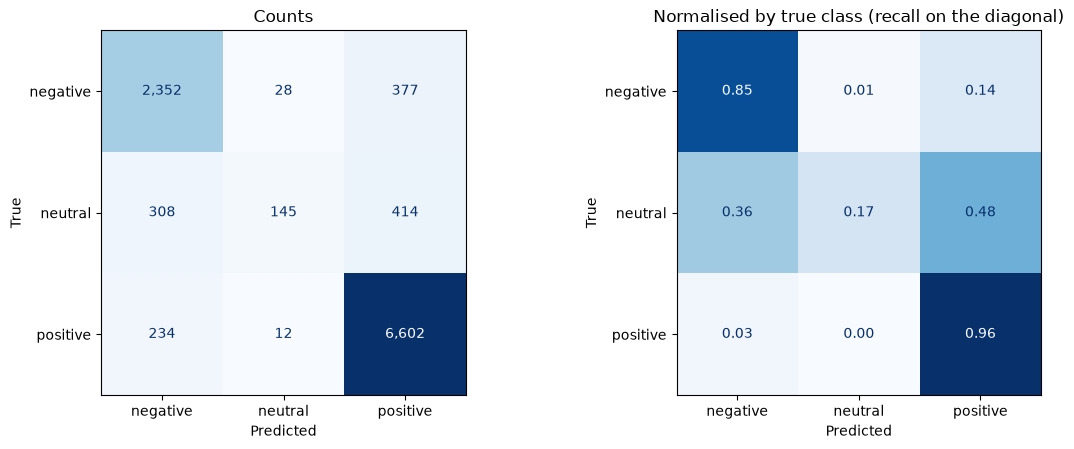

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=","
)
axes[0].set_title("Counts")

ConfusionMatrixDisplay.from_predictions(
    test_labels, predictions, labels=labels_order, normalize="true",
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f",
)
axes[1].set_title("Normalised by true class (recall on the diagonal)")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

The normalised matrix on the right is the more useful of the two. Because it divides by the true
class size, each row sums to 1 and the diagonal reads directly as per-class recall — so the rare
neutral class is visible on equal terms with the majority class, instead of being a faint strip in
the counts plot.

The dominant error is neutral reviews being predicted as positive. That is the model following the
prior: when the evidence is genuinely ambiguous, as it is in a 3-star review, the largest class wins.

In [21]:
errors = pd.DataFrame({
    "review": test_data.loc[test_labels.index],
    "original": data.loc[test_labels.index, "Reviews"],
    "rating": data.loc[test_labels.index, "Rating"],
    "true": test_labels,
    "predicted": predictions,
})
mistakes = errors[(errors["true"] == "neutral") & (errors["predicted"] == "positive")]

for _, row in mistakes.head(4).iterrows():
    print(f"[{row['rating']:.0f} stars, predicted {row['predicted']}]")
    print(" ", str(row["original"])[:200], "\n")

[3 stars, predicted positive]
  Item is good, a touchscreen. Words are so tiny, I'm having difficulty punching in numbers. Sometimes the stylus pen won't, when typing in English, it becomes difficult 1. Because the words are tiny. 2 

[3 stars, predicted positive]
  It's heavy and not quite as responsive as some of the Lumia phones my family has. The display doesn't seem quite as good either. The Lumia phones are a better value. It does have dual sim slots though 

[3 stars, predicted positive]
  Tried it out, but it will not get 4G LTE on straight talk :( only 4G with 9mbps and 2mbps in the best AT&T area. Love the phone, but want more speed. 

[3 stars, predicted positive]
  I just received my brand new phone Posh Mobile L700 White, I received it on time on Aug 6,'2016, the phone looked very nice like I wanted a tablet 7.0 inches had a few minor problems such problems wer 



Reading the misclassified reviews confirms the diagnosis rather than revealing a bug: these are
3-star reviews written in mostly positive language with a reservation attached. The label comes from
the star rating, not from the text, and the text really is closer to positive. A meaningful share of
the "error" here is the labelling scheme, not the classifier.

### Would a different model help?

Naive Bayes was the task requirement. As a reference point, logistic regression on the same features
shows how much of the remaining error is the feature representation rather than the classifier.

In [22]:
%%time
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(train_vectors, train_labels)
logreg_preds = logreg.predict(test_vectors)

results = pd.DataFrame({
    "model": ["majority baseline", "Multinomial NB", "Logistic regression (balanced)"],
    "accuracy": [
        baseline,
        accuracy,
        accuracy_score(test_labels, logreg_preds),
    ],
    "macro F1": [
        f1_score(test_labels, [test_labels.value_counts().idxmax()] * len(test_labels),
                 average="macro", zero_division=0),
        f1_score(test_labels, predictions, average="macro"),
        f1_score(test_labels, logreg_preds, average="macro"),
    ],
}).round(3)
results

CPU times: total: 3.31 s
Wall time: 3.16 s


,model,accuracy,macro F1
0,majority baseline,0.654,0.264
1,Multinomial NB,0.869,0.678
2,Logistic regression (balanced),0.853,0.735


In [23]:
print(classification_report(test_labels, logreg_preds, digits=3))

              precision    recall  f1-score   support

    negative      0.826     0.858     0.842      2757
     neutral      0.379     0.532     0.443       867
    positive      0.954     0.891     0.922      6848

    accuracy                          0.853     10472
   macro avg      0.720     0.760     0.735     10472
weighted avg      0.873     0.853     0.861     10472



`class_weight="balanced"` tells logistic regression to penalise errors on the rare classes in
proportion to how rare they are, which trades a little overall accuracy for a much better neutral
recall. Whether that trade is worth making depends on the application: if the point of the system is
to surface dissatisfied customers, catching the ambiguous middle matters more than the headline
accuracy figure does.

Note that this is also why the comparison is on macro F1 rather than accuracy — on the accuracy
column the balanced model can look *worse* while being more useful.

## Summary

| Task | Result |
| --- | --- |
| 1 | 60,000-review stratified sample; six preprocessing steps, with negations deliberately kept in |
| 2 | Stratified 80/20 split, performed before vectorising to avoid leaking IDF statistics |
| 3 | TF-IDF with unigrams + bigrams and `min_df=3` |
| 4 | `MultinomialNB(alpha=0.1)` |
| 5 | Accuracy well above the majority baseline, but macro F1 much lower — neutral recall is the weak point |
| 6 | Confusion matrix shows the dominant error is neutral → positive |

The main takeaway is that a single accuracy number would have been misleading on this dataset. The
model looks strong until the classes are examined separately, and the per-class view shows most of
the remaining error concentrated in one place — 3-star reviews whose text genuinely reads as
positive.